# Figure 7.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Similar to Figure 3 except only for particle codes, with dashed lines showing $n_\mathrm{p} = 9$ and faded dotted lines $n_\mathrm{p} = 1$.

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

res = 512
root = f'../{res}/src'
n_ps = ['np1', 'np9']
runs = {
    f'dust_particles': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink',
        }
    }
}

np1 Athena samples
	  Total: 10001
	Strided: 1112
	Per 10T: 1000
np1 Athena++ samples
	  Total: 2000
	Strided: 1000
	Per 10T: 222
np1 Pencil samples
	  Total: 2925
	Strided: 1463
	Per 10T: 292
np1 PLUTO samples
	  Total: 1002
	Strided: 1002
	Per 10T: 111
np9 Athena samples
	  Total: 10001
	Strided: 1112
	Per 10T: 1000
np9 Athena++ samples
	  Total: 2001
	Strided: 1001
	Per 10T: 200
np9 Pencil samples
	  Total: 3070
	Strided: 1024
	Per 10T: 341
np9 PLUTO samples
	  Total: 1002
	Strided: 1002
	Per 10T: 111


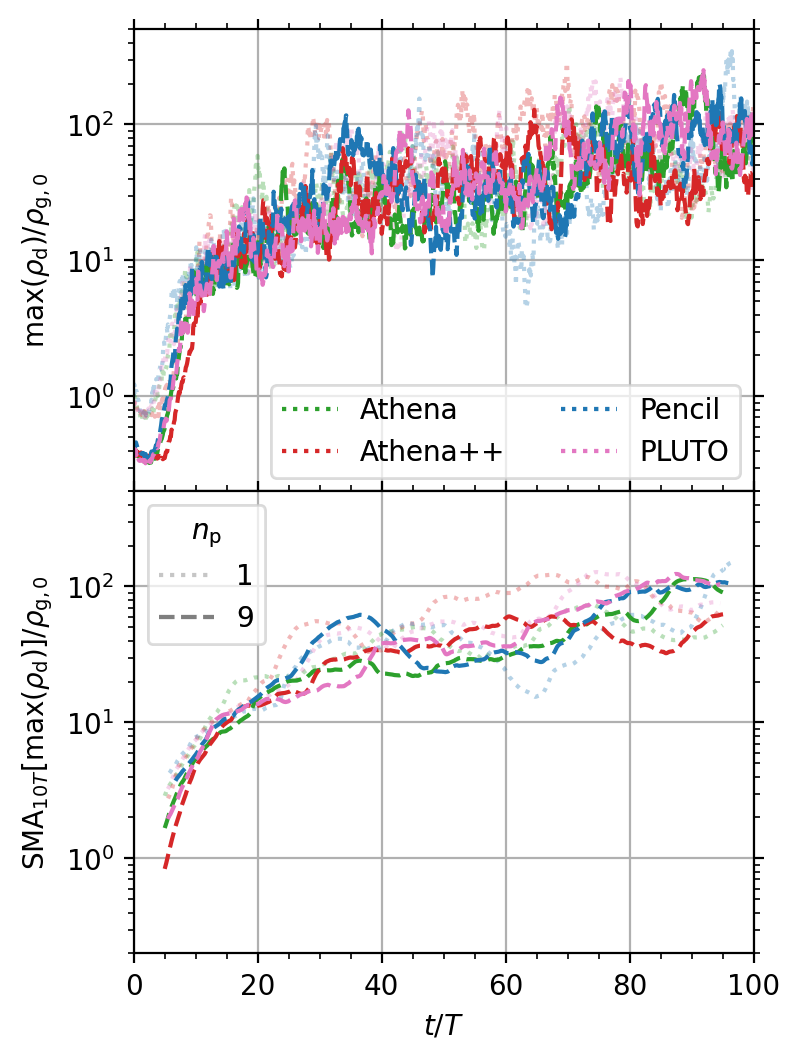

In [2]:
#===============================================================================
def print_samples(n_p, code, t, step, dt, window):
    """Print the number of samples in the time series."""
    print(f'{n_p} {code} samples\n=======================')
    print(f'\t  Total: {len(t)}')
    print(f'\tStrided: {len(t[::step])}')
    print(f'\tPer {dt}T: {window}')

diag = True
dt = 10  # [T]

# Lowest cadence
path = f'{root}/dust_particles/np1/PLUTO'
n_min = len(np.load(f'{path}/time_series.npz')['t'])

# Plot
fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(4, 6), dpi=200)
c_handles, ls_handles = [], []
for n_p in n_ps:
    for key, value in runs.items():
        for code, color in value['codes'].items():
            path = f'{root}/{key}/{n_p}/{code}'
            data = np.load(f'{path}/time_series.npz')
            t = data['t']
            if n_p == 'np1':
                alpha = 0.33
                ls = value['ls']
                c_handles.append(axs[0].plot([],[], c=color, label=code,
                                 ls=ls)[0])
            else:
                alpha = 1.0
                ls = 'dashed'
            # Strided
            step = len(t)//n_min
            if step < 2:
                step = 1 if len(t)%n_min/n_min < 0.5 else 2
            try:
                axs[0].plot(t[::step], data['maxrhod'][::step], alpha=alpha,
                            c=color, ls=ls)
            except KeyError:
                print(code)
            # SMA
            window = len(t)//int(t[-1]/dt)
            print_samples(n_p, code, t, step, dt, window) if diag else None
            df = pd.DataFrame(data=data['maxrhod'], index=t)
            df['sma'] = df.rolling(window, center=True).mean()
            axs[1].plot(df['sma'], alpha=alpha, c=color, ls=ls)

# Custom legends
axs[0].add_artist(axs[0].legend(framealpha=0.5, handles=c_handles,
                                loc='lower right', ncol=2))
ls_handles.append(axs[1].plot([], [], alpha=0.33, c='tab:gray', ls='dotted',
                              label='1')[0])
ls_handles.append(axs[1].plot([], [], c='tab:gray', ls='dashed', label='9')[0])
axs[1].add_artist(axs[1].legend(framealpha=0.5, handles=ls_handles,
                                loc='upper left', title=r'$n_\mathrm{p}$'))

# Format plots
for ax in axs:
    ax.grid()
    ax.minorticks_on()
    ax.set(yscale='log')
    ax.tick_params(axis='both', which='both', top=True, right=True)
axs[0].set(ylabel=rf'$\max(\rho_\mathrm{{d}})/\rho_\mathrm{{g,0}}$', ylim=(2e-1, 5e2))
axs[1].set(xlabel=r'$t/T$', xlim=(0, 100), ylim=(2e-1, 5e2),
           ylabel=rf'$\mathrm{{SMA}}_{{{dt}T}}[\max(\rho_\mathrm{{d}})]/\rho_\mathrm{{g,0}}$')
fig.subplots_adjust(hspace=0)
